In [1]:
import joblib
import os
import torch
from models_def import GoldLSTM_Triple_Pro_v2, GoldGRU_Triple_Pro_v2
from load import load_trading_model
import numpy as np
from models import prepare_all
import pandas as pd
from typing import Literal, Optional
from dataclasses import dataclass, field
import matplotlib.pyplot as plt



In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1", "ibex1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2
TARGET_COLUMN_TRIPLE = 'target_class'

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
model_lstm, scaler_lstm, features_to_use_lstm = load_trading_model(GoldLSTM_Triple_Pro_v2, path=f"../Models/{ASSET}/gold_lstm_triple_pro_v2_shap", device=device)
model_gru, scaler_gru, features_to_use_gru = load_trading_model(GoldGRU_Triple_Pro_v2, path=f"../Models/{ASSET}/gold_gru_triple_pro_v2_shap", device=device)

🚀 Modelo listo. Inputs: 43 features.
🚀 Modelo listo. Inputs: 40 features.


In [5]:
models_bundle = {
        "lstm": {"model": model_lstm, "scaler": scaler_lstm, "features": features_to_use_lstm},
        "gru":  {"model": model_gru,  "scaler": scaler_gru,  "features": features_to_use_gru},
    }

In [6]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")
info_json = pd.read_json("../Data/futuros_specs_extend.json")


Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


In [7]:
info = info_json[ASSET[:2].upper()]

In [ ]:
@dataclass
class PyramidConfig:
    # Señal
    base_threshold: float = 0.70        # Umbral mínimo de confianza para la 1ª posición
    threshold_mult: float = 1.05        # Multiplicador por cada posición adicional
    max_positions: int = 5              # Máximo de posiciones en una dirección
 
    # Horizonte / lookback
    lookback: int = 48                  # Ventana de secuencia que esperan los modelos
    pred_interval: int = 1              # Cada cuántas velas se re-predice (1 = cada vela)
 
    # TP / SL (en múltiplos de ATR)
    tp_atr_mult: float = 1.8            # Multiplicador ATR para Take Profit
    sl_atr_mult: float = 1.2            # Multiplicador ATR para Stop Loss
    atr_col: str = "atr"               # Nombre de la columna ATR en el DataFrame
 
    # Costos (se calculan desde spec si se pasan, pero se pueden sobreescribir)
    cost_ticks: Optional[float] = None  # Si None, se calcula desde spec
 
    # Comportamiento avanzado
    close_on_hold: bool = True          # Si True, HOLD cierra todas las posiciones
    close_on_reversal: bool = True      # Si True, señal contraria cierra y revierte
    slippage_pct: float = 0.01         # Slippage adicional como % del precio de entrada

In [9]:
config = PyramidConfig(
        base_threshold    = 0.60,
        threshold_mult    = 1.10,
        max_positions     = 5,
        lookback          = 48,
        pred_interval     = 1,
        tp_atr_mult       = 1.4,
        sl_atr_mult       = 1.2,
        atr_col           = "atr",
        cost_ticks        = None,   # Se calcula desde spec: ~2.5 ticks para GC1
        close_on_hold     = True,
        close_on_reversal = True,
    )

In [10]:
def compute_cost_ticks(spec: dict) -> float:
    """Calcula el coste total por operación (round-trip) en ticks."""
    tick_val = float(spec["tick_value"])
    fees_rt = (float(spec["approx_total_fee_per_side"]) * 2.0) / tick_val
    slip = float(spec.get("min_slippage_ticks", 1.0))
    spread = float(spec.get("min_spread_ticks", 1.0))
    return fees_rt + slip + spread

In [11]:
def sanity_check(df: pd.DataFrame, spec: dict, config: PyramidConfig) -> None:
    """Imprime un resumen de los parámetros para verificar que los números tienen sentido."""
    tick_size  = float(spec["tick_size"])
    tick_value = float(spec["tick_value"])
    cost_ticks = config.cost_ticks if config.cost_ticks is not None else compute_cost_ticks(spec)
 
    atr_mean   = df[config.atr_col].mean()
    price_mean = df["close"].mean()
    tp_ticks   = atr_mean * config.tp_atr_mult / tick_size
    sl_ticks   = atr_mean * config.sl_atr_mult / tick_size
 
    print("=" * 55)
    print("  SANITY CHECK — parámetros del backtest")
    print("=" * 55)
    print(f"  Precio medio        : ${price_mean:,.2f}")
    print(f"  ATR medio           : ${atr_mean:.4f}  ({atr_mean/price_mean*100:.3f}% del precio)")
    print(f"  Tick size / value   : {tick_size} / ${tick_value}")
    print(f"  Coste round-trip    : {cost_ticks:.2f} ticks  (${cost_ticks*tick_value:.2f})")
    print(f"  TP medio esperado   : {tp_ticks:.1f} ticks  (${tp_ticks*tick_value:.2f})")
    print(f"  SL medio esperado   : {sl_ticks:.1f} ticks  (${sl_ticks*tick_value:.2f})")
    print(f"  R:R neto (aprox)    : {(tp_ticks - cost_ticks)/(sl_ticks + cost_ticks):.2f}")
    print(f"  Umbral pos #1       : {config.base_threshold:.2f}")
    print(f"  Umbral pos #2       : {config.base_threshold * config.threshold_mult:.2f}")
    print(f"  Umbral pos #3       : {config.base_threshold * config.threshold_mult**2:.2f}")
    print(f"  Lookback            : {config.lookback} velas")
    print("=" * 55)

In [12]:
def get_ensemble_probs(
    df: pd.DataFrame,
    step: int,
    models_bundle: dict,
    lookback: int = 48,
    device: str = "cpu",
) -> np.ndarray:
    """
    Devuelve probabilidades promediadas [p_sell, p_hold, p_buy].
 
    models_bundle = {
        'lstm': {'model': ..., 'scaler': ..., 'features': [...]},
        'gru':  {'model': ..., 'scaler': ..., 'features': [...]},
    }
    """
    start_idx = step - lookback + 1
    if start_idx < 0:
        return np.array([0.0, 1.0, 0.0])
 
    window_raw = df.iloc[start_idx : step + 1]
 
    if len(window_raw) < lookback:
        return np.array([0.0, 1.0, 0.0])
 
    all_probs = []
 
    for key in ["lstm", "gru"]:
        m_info   = models_bundle[key]
        features = m_info["features"]
        scaler   = m_info["scaler"]
        model    = m_info["model"]
 
        missing = [f for f in features if f not in window_raw.columns]
        if missing:
            raise ValueError(f"Modelo '{key}' requiere features faltantes: {missing}")
 
        X_raw    = window_raw[features].values
        X_scaled = scaler.transform(X_raw)
        X_tensor = torch.FloatTensor(X_scaled).unsqueeze(0).to(device)
 
        with torch.no_grad():
            output = model(X_tensor)
            probs  = torch.softmax(output, dim=1).cpu().numpy()[0]
            all_probs.append(probs)
 
    return np.mean(all_probs, axis=0)

In [13]:
def _compute_metrics(trades: list[dict], equity_curve: np.ndarray, tick_value: float) -> dict:
    if not trades:
        return {"n_trades": 0}
 
    pnls   = np.array([t["pnl_ticks"] for t in trades])
    wins   = pnls[pnls > 0]
    losses = pnls[pnls < 0]
 
    roll_max  = np.maximum.accumulate(equity_curve)
    max_dd    = float((roll_max - equity_curve).max())
 
    gross_profit  = float(wins.sum())        if len(wins)   else 0.0
    gross_loss    = float(abs(losses.sum())) if len(losses) else 1e-9
    profit_factor = gross_profit / gross_loss
 
    std_ret = pnls.std() if pnls.std() > 0 else 1e-9
    sharpe  = (pnls.mean() / std_ret) * np.sqrt(252)
 
    def _group_stats(items):
        v = np.array(items)
        return {"n": len(v), "avg_pnl": float(v.mean()), "win_rate": float((v > 0).mean())}
 
    by_reason: dict[str, list] = {}
    by_level:  dict[int, list] = {}
    for t in trades:
        by_reason.setdefault(t.get("exit_reason", "unknown"), []).append(t["pnl_ticks"])
        by_level.setdefault(t.get("n_pos", 1), []).append(t["pnl_ticks"])
 
    return {
        "n_trades":           len(trades),
        "win_rate":           float(len(wins) / len(trades)),
        "avg_win_ticks":      float(wins.mean())   if len(wins)   else 0.0,
        "avg_loss_ticks":     float(losses.mean()) if len(losses) else 0.0,
        "profit_factor":      profit_factor,
        "sharpe_approx":      float(sharpe),
        "max_drawdown_ticks": max_dd,
        "max_drawdown_usd":   max_dd * tick_value,
        "total_pnl_ticks":    float(pnls.sum()),
        "total_pnl_usd":      float(pnls.sum() * tick_value),
        "by_exit_reason":     {r: _group_stats(v) for r, v in by_reason.items()},
        "by_pyramid_level":   {l: _group_stats(v) for l, v in by_level.items()},
    }

In [14]:
def run_pyramid_backtest(
    df: pd.DataFrame,
    models_bundle: dict,
    spec: dict,
    conf_threshold: float = 0.60,
    config: Optional[PyramidConfig] = None,
    device: str = "cpu",
    verbose: bool = False,
    debug_trades: int = 0,
) -> dict:
    """
    Ejecuta el backtest de piramidación completo.
 
    Parámetros
    ----------
    df            : DataFrame con OHLCV + indicadores. Requiere: open, high, low, close, <atr_col>.
    models_bundle : {'lstm': {'model':..,'scaler':..,'features':..}, 'gru': {...}}
    spec          : Especificación del contrato.
    config        : PyramidConfig. Si None usa valores por defecto.
    device        : "cpu" o "cuda".
    verbose       : Log de cada vela con señal.
    debug_trades  : Imprime las primeras N operaciones cerradas con detalle.
 
    Retorna
    -------
    dict con cash_ticks, cash_usd, trades, equity_curve, metrics.
    """
    if config is None:
        config = PyramidConfig()
 
    tick_size  = float(spec["tick_size"])
    tick_value = float(spec["tick_value"])
    cost_ticks = config.cost_ticks if config.cost_ticks is not None else compute_cost_ticks(spec)
 
    df = df.reset_index(drop=True)
    n  = len(df)
 
    cash: float = 0.0
    active_trades: list[dict] = []
    closed_trades: list[dict] = []
    equity_curve  = np.zeros(n)
    debug_count   = 0
 
    def _close_trade(trade: dict, exit_price: float, exit_reason: str, bar_idx: int) -> float:
        """
        Cierra una operación. PnL neto en ticks:
            gross = dirección × (exit - entry) / tick_size
            net   = gross - cost_ticks
 
        Sin slippage_pct: el coste de GC1 es ~2.5 ticks round-trip, no un % del precio.
        """
        nonlocal debug_count
        direction   = 1 if trade["type"] == "buy" else -1
        gross_ticks = direction * (exit_price - trade["entry"]) / tick_size
        net_ticks   = gross_ticks - cost_ticks
 
        trade.update({
            "exit_price":  exit_price,
            "exit_bar":    bar_idx,
            "exit_reason": exit_reason,
            "pnl_ticks":   net_ticks,
            "pnl_usd":     net_ticks * tick_value,
        })
        closed_trades.append(trade)
 
        if debug_count < debug_trades:
            print(f"\n  [DEBUG TRADE #{debug_count+1}]")
            print(f"    Tipo    : {trade['type'].upper()}  |  Nivel pirámide: #{trade['n_pos']}")
            print(f"    Entry   : ${trade['entry']:.2f}  (bar {trade['entry_bar']})")
            print(f"    Exit    : ${exit_price:.2f}  (bar {bar_idx})  [{exit_reason}]")
            print(f"    TP/SL   : ${trade['tp']:.2f} / ${trade['sl']:.2f}")
            print(f"    Bruto   : {gross_ticks:+.1f} ticks")
            print(f"    Coste   : -{cost_ticks:.2f} ticks")
            print(f"    Neto    : {net_ticks:+.1f} ticks  (${net_ticks*tick_value:+.2f})")
            debug_count += 1
 
        if verbose:
            print(f"  [CLOSE] bar={bar_idx} | {trade['type'].upper()} "
                  f"entry={trade['entry']:.2f} exit={exit_price:.2f} "
                  f"pnl={net_ticks:+.1f}t (${trade['pnl_usd']:+.0f}) [{exit_reason}]")
        return net_ticks
 
    for i in range(n):
        current_high  = df["high"].iloc[i]
        current_low   = df["low"].iloc[i]
        current_close = df["close"].iloc[i]
 
        # ── 1. GESTIÓN DE SL/TP ─────────────────────────────────────────────
        still_open = []
        for trade in active_trades:
            tp, sl = trade["tp"], trade["sl"]
            closed = False
 
            if trade["type"] == "buy":
                if current_high >= tp and current_low <= sl:
                    cash += _close_trade(trade, sl, "SL_conflict", i)
                    closed = True
                elif current_high >= tp:
                    cash += _close_trade(trade, tp, "TP", i)
                    closed = True
                elif current_low <= sl:
                    cash += _close_trade(trade, sl, "SL", i)
                    closed = True
            else:
                if current_low <= tp and current_high >= sl:
                    cash += _close_trade(trade, sl, "SL_conflict", i)
                    closed = True
                elif current_low <= tp:
                    cash += _close_trade(trade, tp, "TP", i)
                    closed = True
                elif current_high >= sl:
                    cash += _close_trade(trade, sl, "SL", i)
                    closed = True
 
            if not closed:
                still_open.append(trade)
 
        active_trades = still_open
 
        # ── 2. INFERENCIA ────────────────────────────────────────────────────
        if i < config.lookback:
            equity_curve[i] = cash
            continue
 
        if i % config.pred_interval != 0:
            equity_curve[i] = cash
            continue
 
        probs      = get_ensemble_probs(df, i, models_bundle, config.lookback, device)
        # pred_label = int(np.argmax(probs))
        # Índices: 0 = Sell, 1 = Hold, 2 = Buy
        prob_sell = probs[0]
        prob_buy  = probs[2]

        # Lógica de decisión
        if prob_buy > conf_threshold:
            pred_label = 2  # BUY
        elif prob_sell > conf_threshold:
            pred_label = 0  # SELL
        else:
            pred_label = 1  # HOLD (por defecto si no hay confianza)
        confidence = float(probs[pred_label])
 
        has_buys  = any(t["type"] == "buy"  for t in active_trades)
        has_sells = any(t["type"] == "sell" for t in active_trades)
 
        if verbose:
            label_str = {0: "SELL", 1: "HOLD", 2: "BUY"}[pred_label]
            print(f"bar={i} | {label_str} conf={confidence:.3f} | pos={len(active_trades)} | cash={cash:.1f}t")
 
        # ── 3. CIERRES POR SEÑAL ─────────────────────────────────────────────
        if pred_label == 1 and config.close_on_hold and active_trades:
            for trade in active_trades:
                cash += _close_trade(trade, current_close, "signal_HOLD", i)
            active_trades = []
 
        elif config.close_on_reversal:
            if pred_label == 0 and has_buys:
                for trade in [t for t in active_trades if t["type"] == "buy"]:
                    cash += _close_trade(trade, current_close, "reversal_SELL", i)
                active_trades = [t for t in active_trades if t["type"] != "buy"]
            elif pred_label == 2 and has_sells:
                for trade in [t for t in active_trades if t["type"] == "sell"]:
                    cash += _close_trade(trade, current_close, "reversal_BUY", i)
                active_trades = [t for t in active_trades if t["type"] != "sell"]
 
        # ── 4. PIRAMIDACIÓN ──────────────────────────────────────────────────
        if pred_label in [0, 2] and i + 1 < n:
            trade_type = "buy" if pred_label == 2 else "sell"
            wrong_dir  = (trade_type == "buy" and has_sells) or \
                         (trade_type == "sell" and has_buys)
 
            if not wrong_dir:
                n_pos             = len(active_trades)
                dynamic_threshold = config.base_threshold * (config.threshold_mult ** n_pos)
 
                if confidence >= dynamic_threshold and n_pos < config.max_positions:
                    entry_price = df["open"].iloc[i + 1]
                    atr_val     = df[config.atr_col].iloc[i]
 
                    if trade_type == "buy":
                        tp_price = entry_price + atr_val * config.tp_atr_mult
                        sl_price = entry_price - atr_val * config.sl_atr_mult
                    else:
                        tp_price = entry_price - atr_val * config.tp_atr_mult
                        sl_price = entry_price + atr_val * config.sl_atr_mult
 
                    active_trades.append({
                        "type":      trade_type,
                        "entry":     entry_price,
                        "tp":        tp_price,
                        "sl":        sl_price,
                        "entry_bar": i,
                        "n_pos":     n_pos + 1,
                    })
 
                    if verbose:
                        print(f"  [OPEN] bar={i} | {trade_type.upper()} "
                              f"entry={entry_price:.2f} TP={tp_price:.2f} SL={sl_price:.2f} "
                              f"conf={confidence:.3f} thresh={dynamic_threshold:.3f} [pos #{n_pos+1}]")
 
        equity_curve[i] = cash
 
    # Cerrar posiciones abiertas al final
    last_close = df["close"].iloc[-1]
    for trade in active_trades:
        cash += _close_trade(trade, last_close, "end_of_data", n - 1)
    equity_curve[-1] = cash
 
    metrics = _compute_metrics(closed_trades, equity_curve, tick_value)
 
    return {
        "cash_ticks":   cash,
        "cash_usd":     cash * tick_value,
        "trades":       closed_trades,
        "equity_curve": equity_curve,
        "metrics":      metrics,
    }

In [15]:
def print_results(results: dict) -> None:
    m = results["metrics"]
    print("\n" + "=" * 55)
    print(f"  PnL total : {results['cash_ticks']:+.1f} ticks  |  ${results['cash_usd']:+,.0f}")
    print(f"  Operaciones: {m['n_trades']}  |  Win rate: {m['win_rate']:.1%}")
    print(f"  Profit factor: {m['profit_factor']:.2f}  |  Sharpe≈{m['sharpe_approx']:.2f}")
    print(f"  Max DD: {m['max_drawdown_ticks']:.1f}t  |  ${m['max_drawdown_usd']:,.0f}")
    print(f"  Avg win: {m['avg_win_ticks']:+.1f}t  |  Avg loss: {m['avg_loss_ticks']:+.1f}t")
    print("\n  Por motivo de cierre:")
    for reason, s in sorted(m.get("by_exit_reason", {}).items()):
        print(f"    {reason:<20} n={s['n']:>5}  avg={s['avg_pnl']:+.1f}t  wr={s['win_rate']:.1%}")
    print("\n  Por nivel de pirámide:")
    for lvl, s in sorted(m.get("by_pyramid_level", {}).items()):
        print(f"    Pos #{lvl}: n={s['n']}  avg={s['avg_pnl']:+.1f}t  wr={s['win_rate']:.1%}")
    print("=" * 55)

In [16]:
sanity_check(df_final, info, config)

  SANITY CHECK — parámetros del backtest
  Precio medio        : $1,494.67
  ATR medio           : $4.0306  (0.270% del precio)
  Tick size / value   : 0.1 / $10.0
  Coste round-trip    : 2.50 ticks  ($25.00)
  TP medio esperado   : 56.4 ticks  ($564.29)
  SL medio esperado   : 48.4 ticks  ($483.68)
  R:R neto (aprox)    : 1.06
  Umbral pos #1       : 0.60
  Umbral pos #2       : 0.66
  Umbral pos #3       : 0.73
  Lookback            : 48 velas


In [19]:
results = run_pyramid_backtest(
        df_final, models_bundle, info, 0.6, config,
        device=device,
        verbose=False,
        debug_trades=5,
    )


  [DEBUG TRADE #1]
    Tipo    : BUY  |  Nivel pirámide: #1
    Entry   : $1368.60  (bar 439)
    Exit    : $1364.92  (bar 441)  [SL]
    TP/SL   : $1372.89 / $1364.92
    Bruto   : -36.8 ticks
    Coste   : -2.50 ticks
    Neto    : -39.3 ticks  ($-392.61)

  [DEBUG TRADE #2]
    Tipo    : BUY  |  Nivel pirámide: #2
    Entry   : $1369.80  (bar 440)
    Exit    : $1366.10  (bar 441)  [SL]
    TP/SL   : $1374.11 / $1366.10
    Bruto   : -37.0 ticks
    Coste   : -2.50 ticks
    Neto    : -39.5 ticks  ($-394.79)

  [DEBUG TRADE #3]
    Tipo    : BUY  |  Nivel pirámide: #1
    Entry   : $1355.90  (bar 441)
    Exit    : $1349.93  (bar 442)  [SL]
    TP/SL   : $1362.87 / $1349.93
    Bruto   : -59.7 ticks
    Coste   : -2.50 ticks
    Neto    : -62.2 ticks  ($-622.14)

  [DEBUG TRADE #4]
    Tipo    : BUY  |  Nivel pirámide: #1
    Entry   : $1343.90  (bar 442)
    Exit    : $1336.12  (bar 443)  [SL]
    TP/SL   : $1352.98 / $1336.12
    Bruto   : -77.8 ticks
    Coste   : -2.50 ticks
  

In [17]:
# Analizar distribución real de predicciones en el período de test
probs_all = []
labels_all = []

for i in range(config.lookback, len(df_final)):
    p = get_ensemble_probs(df_final, i, models_bundle, config.lookback, device)
    probs_all.append(p)
    labels_all.append(np.argmax(p))

probs_all  = np.array(probs_all)
labels_all = np.array(labels_all)

print("Distribución de señales predichas:")
for i, name in enumerate(["SELL", "HOLD", "BUY"]):
    pct = (labels_all == i).mean()
    conf_mean = probs_all[labels_all == i, i].mean() if (labels_all == i).any() else 0
    print(f"  {name}: {pct:.1%} de las velas  |  conf media: {conf_mean:.3f}")

print(f"\nConfianza media global: {probs_all.max(axis=1).mean():.3f}")
print(f"% velas con conf > 0.60: {(probs_all.max(axis=1) > 0.60).mean():.1%}")
print(f"% velas con conf > 0.70: {(probs_all.max(axis=1) > 0.70).mean():.1%}")

# Ver si hay sesgo hacia BUY en momentos bajistas
# Compara señal predicha vs dirección real del precio siguiente
df_eval = df_final.iloc[config.lookback:].copy().reset_index(drop=True)
df_eval["pred"] = labels_all
df_eval["next_ret"] = df_eval["close"].shift(-1) - df_eval["close"]
df_eval["correct_dir"] = (
    ((df_eval["pred"] == 2) & (df_eval["next_ret"] > 0)) |
    ((df_eval["pred"] == 0) & (df_eval["next_ret"] < 0))
)

print("\nAlineación señal vs dirección real (solo BUY/SELL):")
mask = df_eval["pred"] != 1
print(f"  Acierto direccional: {df_eval.loc[mask, 'correct_dir'].mean():.1%}")

buy_mask  = df_eval["pred"] == 2
sell_mask = df_eval["pred"] == 0
print(f"  BUY correctos : {df_eval.loc[buy_mask,  'correct_dir'].mean():.1%}")
print(f"  SELL correctos: {df_eval.loc[sell_mask, 'correct_dir'].mean():.1%}")

Distribución de señales predichas:
  SELL: 43.5% de las velas  |  conf media: 0.568
  HOLD: 28.8% de las velas  |  conf media: 0.647
  BUY: 27.6% de las velas  |  conf media: 0.557

Confianza media global: 0.588
% velas con conf > 0.60: 39.3%
% velas con conf > 0.70: 12.6%

Alineación señal vs dirección real (solo BUY/SELL):
  Acierto direccional: 50.1%
  BUY correctos : 50.6%
  SELL correctos: 49.7%


In [20]:
print_results(results)


  PnL total : -21704.1 ticks  |  $-217,041
  Operaciones: 10509  |  Win rate: 46.9%
  Profit factor: 0.89  |  Sharpe≈-0.78
  Max DD: 38878.8t  |  $388,788
  Avg win: +36.4t  |  Avg loss: -36.0t

  Por motivo de cierre:
    SL                   n= 4197  avg=-41.9t  wr=0.0%
    SL_conflict          n=  164  avg=-38.6t  wr=0.0%
    TP                   n= 3280  avg=+45.4t  wr=100.0%
    reversal_BUY         n=    1  avg=+67.5t  wr=100.0%
    signal_HOLD          n= 2867  avg=+4.0t  wr=57.4%

  Por nivel de pirámide:
    Pos #1: n=7424  avg=-2.8t  wr=46.4%
    Pos #2: n=2799  avg=-1.4t  wr=47.3%
    Pos #3: n=263  avg=+8.9t  wr=54.4%
    Pos #4: n=22  avg=+33.8t  wr=77.3%
    Pos #5: n=1  avg=+61.6t  wr=100.0%


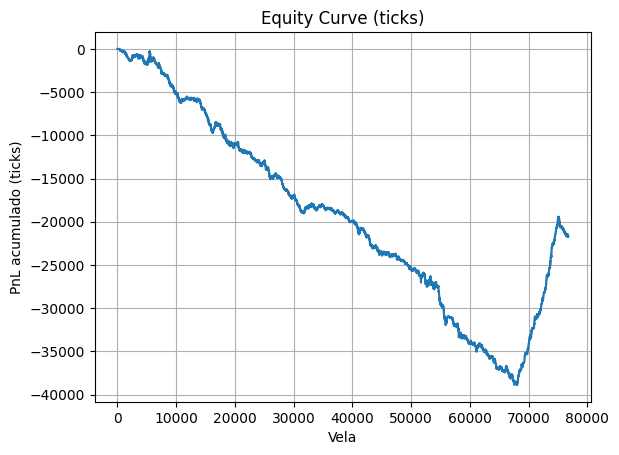

In [21]:
plt.plot(results["equity_curve"])
plt.title("Equity Curve (ticks)")
plt.xlabel("Vela")
plt.ylabel("PnL acumulado (ticks)")
plt.grid(True)
plt.show()

In [ ]:
print(df_final[["open", "high", "low", "close", "atr"]].describe())
print("\n--- Primeras filas ---")
print(df_final[["open", "high", "low", "close", "atr"]].head(10))
print("\n--- Rango de ATR ---")
print(f"ATR min: {df_final['atr'].min():.4f}")
print(f"ATR max: {df_final['atr'].max():.4f}")
print(f"ATR mean: {df_final['atr'].mean():.4f}")
print(f"Close mean: {df_final['close'].mean():.4f}")
print(f"\nTick size en spec: {spec['tick_size']}")
print(f"Tick value en spec: {spec['tick_value']}")

               open          high           low         close           atr
count  76740.000000  76740.000000  76740.000000  76740.000000  76740.000000
mean    1494.681893   1496.640576   1492.637215   1494.671983      4.030628
std      264.420227    264.867770    263.909690    264.414160      2.226007
min     1048.900000   1049.500000   1045.400000   1048.916617      0.766898
25%     1269.600000   1271.000000   1268.200000   1269.597779      2.578064
50%     1403.500000   1405.950000   1401.000000   1403.528781      3.506305
75%     1741.100000   1743.800000   1738.200000   1741.050337      4.815533
max     2083.900000   2089.200000   2081.800000   2083.999774     29.179105

--- Primeras filas ---
     open    high     low        close       atr
0  1293.7  1294.3  1290.6  1291.383032  3.397844
1  1291.5  1292.1  1290.1  1291.713842  3.211464
2  1291.7  1296.5  1291.5  1294.029050  3.449936
3  1293.9  1295.5  1293.6  1294.513730  3.243278
4  1294.5  1295.0  1292.1  1294.465889  3.19750